# Online Purchase Intention Prediction

## Preprocessing & Modelling

### Purpose of this notebook

This notebook picks up where `01_data_audit_eda.ipynb` left off. It builds a reproducible preprocessing pipeline, establishes baseline models, trains and tunes an XGBoost model, and evaluates performance.

The analysis focuses on:

- Train/test split (stratified, given the ~15.5% class imbalance found in notebook 1)
- Encoding of categorical features
- Dummy Classifier and untuned Random Forest baselines
- Initial XGBoost model with class-imbalance handling
- Model comparison with and without `PageValues` (per the leakage discussion in notebook 1)
- Hyperparameter tuning (Randomized Search → Grid Search → Manual Search)
- Feature importance and business interpretation

### Input

This notebook loads the same raw dataset used in notebook 1 (`../data/raw/online_shoppers_intention.csv`). No rows were removed in notebook 1 (the 125 duplicates were intentionally retained), so the raw file is reloaded here directly.

## 1. Imports & Setup

In [2]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

SEED = 1

## 2. Load Data

In [3]:
shopping_df = pd.read_csv("../data/raw/online_shoppers_intention.csv")
shopping_df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## 3. Define X / y

In [4]:
X = shopping_df.drop("Revenue", axis=1)
y = shopping_df["Revenue"]

# Confirm class balance (should match notebook 1: ~84.5% / ~15.5%)
y.value_counts(normalize=True)

Revenue
False    0.845255
True     0.154745
Name: proportion, dtype: float64

## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')

X_train shape: (9864, 17)
X_test shape:  (2466, 17)


In [6]:
# Verify stratify worked as expected
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Revenue
False    0.845296
True     0.154704
Name: proportion, dtype: float64
Revenue
False    0.845093
True     0.154907
Name: proportion, dtype: float64


## 5. Categorical vs Numerical Columns

`OperatingSystems`, `Browser`, `Region`, and `TrafficType` are stored as `int64` but are actually category codes (no meaningful order), so they're converted to `str` before splitting columns by dtype.

In [7]:
cols_to_convert = ['OperatingSystems', 'Browser', 'Region', 'TrafficType']
X_train[cols_to_convert] = X_train[cols_to_convert].astype(str)
X_test[cols_to_convert] = X_test[cols_to_convert].astype(str)

numerical_cols = X_train.select_dtypes(include='number').columns
categorical_cols = X_train.select_dtypes(include='object').columns

print(numerical_cols)
print(categorical_cols)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'],
      dtype='object')
Index(['Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType',
       'VisitorType'],
      dtype='object')


### Feature inclusion note

`Weekend` is stored as a Boolean feature and is therefore not included in the numerical or categorical feature lists used below. The EDA showed only a very weak individual correlation with `Revenue` (approximately 0.03), so we retain its exclusion for the current model. This is a modelling choice rather than proof that `Weekend` has no possible predictive value, since correlation does not capture every nonlinear relationship or interaction.

In [8]:
# Check cardinality before encoding
for col in categorical_cols:
    print(col, X_train[col].nunique())

Month 10
OperatingSystems 8
Browser 13
Region 9
TrafficType 20
VisitorType 3


## 6. One-Hot Encoding

In [9]:
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')

X_train_cat_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_cat_encoded = encoder.transform(X_test[categorical_cols])

encoded_cols = encoder.get_feature_names_out(categorical_cols)
X_train_cat_df = pd.DataFrame(X_train_cat_encoded, columns=encoded_cols, index=X_train.index)
X_test_cat_df = pd.DataFrame(X_test_cat_encoded, columns=encoded_cols, index=X_test.index)

X_train_cat_df.head()

,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,OperatingSystems_2,...,TrafficType_20,TrafficType_3,TrafficType_4,TrafficType_5,TrafficType_6,TrafficType_7,TrafficType_8,TrafficType_9,VisitorType_Other,VisitorType_Returning_Visitor
7349,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8611,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3877,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2625,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3508,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## 7. Combine Numerical + Encoded Categorical Features

In [10]:
X_train_final = pd.concat([X_train[numerical_cols], X_train_cat_df], axis=1)
X_test_final = pd.concat([X_test[numerical_cols], X_test_cat_df], axis=1)

print(X_train_final.shape)
print(X_test_final.shape)

(9864, 67)
(2466, 67)


## 8.1 Baseline Models - Dummy Classifier

In [11]:
dummy = DummyClassifier(strategy='most_frequent', random_state=SEED)
dummy.fit(X_train_final, y_train)
y_pred_dummy = dummy.predict(X_test_final)

print(classification_report(y_test, y_pred_dummy))

              precision    recall  f1-score   support

       False       0.85      1.00      0.92      2084
        True       0.00      0.00      0.00       382

    accuracy                           0.85      2466
   macro avg       0.42      0.50      0.46      2466
weighted avg       0.71      0.85      0.77      2466



/opt/anaconda3/envs/anaconda-2025.12-py3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/anaconda-2025.12-py3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/anaconda-2025.12-py3.13/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

## 8.2 Baseline Models - Random Forest

In [12]:
rf = RandomForestClassifier(random_state=SEED)
rf.fit(X_train_final, y_train)
y_pred_rf = rf.predict(X_test_final)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

       False       0.92      0.97      0.95      2084
        True       0.78      0.55      0.65       382

    accuracy                           0.91      2466
   macro avg       0.85      0.76      0.80      2466
weighted avg       0.90      0.91      0.90      2466



## 9.1 XGBoost — Initial Model

In [13]:
xgb = XGBClassifier(random_state=SEED, eval_metric='logloss')
xgb.fit(X_train_final, y_train)
y_pred_xgb = xgb.predict(X_test_final)

print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

       False       0.93      0.96      0.94      2084
        True       0.73      0.59      0.65       382

    accuracy                           0.90      2466
   macro avg       0.83      0.77      0.80      2466
weighted avg       0.90      0.90      0.90      2466



## 9.2 XGBoost — Handling Class Imbalance (scale_pos_weight)

In [14]:
scale_pos_weight = (y_train == False).sum() / (y_train == True).sum()
print("scale_pos_weight:", scale_pos_weight)

xgb_weighted = XGBClassifier(random_state=SEED, eval_metric='logloss', 
                               scale_pos_weight=scale_pos_weight)
xgb_weighted.fit(X_train_final, y_train)
y_pred_xgb_weighted = xgb_weighted.predict(X_test_final)

print(classification_report(y_test, y_pred_xgb_weighted))

scale_pos_weight: 5.463958060288335
              precision    recall  f1-score   support

       False       0.94      0.91      0.93      2084
        True       0.59      0.71      0.65       382

    accuracy                           0.88      2466
   macro avg       0.77      0.81      0.79      2466
weighted avg       0.89      0.88      0.88      2466



## 10. Hyperparameter Tuning — Random Search (XGBoost)

In [15]:
grid = {
    'n_estimators': [300, 500, 700, 1000],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_lambda': [1, 3, 10, 20]
}

xgb_base = XGBClassifier(random_state=SEED, eval_metric='logloss',
                          scale_pos_weight=scale_pos_weight)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=grid,
    n_iter=10,
    scoring='f1',
    cv=4,
    random_state=SEED,
    n_jobs=-1
)

random_search.fit(X_train_final, y_train)

print("Best parameters:", random_search.best_params_)
print("Best CV F1-score:", random_search.best_score_)

Best parameters: {'subsample': 0.8, 'reg_lambda': 1, 'n_estimators': 300, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
Best CV F1-score: 0.6697947458741189


## 11. Hyperparameter Tuning — Grid Search (XGBoost)

In [16]:
grid_narrow = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.02, 0.03, 0.05],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'reg_lambda': [1, 2, 5]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=grid_narrow,
    scoring='f1',
    cv=4,
    n_jobs=-1
)

grid_search.fit(X_train_final, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

Best parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.02, 'n_estimators': 400, 'reg_lambda': 1, 'subsample': 0.8}
Best CV F1-score: 0.6756449139205163


## 12.1 Hyperparameter Tuning — Manual Search - Attempt 1

In [17]:
xgb_manual = XGBClassifier(
    n_estimators=400,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_lambda=1,
    random_state=SEED,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

s4f = StratifiedKFold(n_splits=4, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(xgb_manual, X_train_final, y_train, cv=s4f, scoring='f1')

print("CV F1-score:", cv_scores.mean())

CV F1-score: 0.6698478291616558


## 12.2 Hyperparameter Tuning — Manual Search - Attempt 2

In [18]:
xgb_manual_v2 = XGBClassifier(
    n_estimators=500,
    learning_rate=0.015,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_lambda=1,
    random_state=SEED,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

cv_scores_v2 = cross_val_score(xgb_manual_v2, X_train_final, y_train, cv=s4f, scoring='f1')
print("CV F1-score (v2):", cv_scores_v2.mean())

CV F1-score (v2): 0.673641624065834


## 13. Final Model

In [19]:
final_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.02,
    subsample=0.8,
    colsample_bytree=0.7,
    reg_lambda=1,
    random_state=SEED,
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

final_model.fit(X_train_final, y_train)

y_pred_final = final_model.predict(X_test_final)
print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

       False       0.96      0.89      0.92      2084
        True       0.57      0.82      0.67       382

    accuracy                           0.88      2466
   macro avg       0.77      0.85      0.80      2466
weighted avg       0.90      0.88      0.88      2466



### 13.1 Final Model Evaluation

Because purchases represent only approximately 15.5% of sessions, accuracy alone can be misleading. The final model is therefore evaluated using precision, recall, F1-score and PR-AUC for the positive class (`Revenue=True`). A confusion matrix shows the types of correct and incorrect predictions, while the precision-recall curve illustrates the trade-off between identifying more buyers and generating more false positives.

,Accuracy,Precision,Recall,F1-score,PR-AUC
Final XGBoost,0.876,0.568,0.817,0.67,0.785


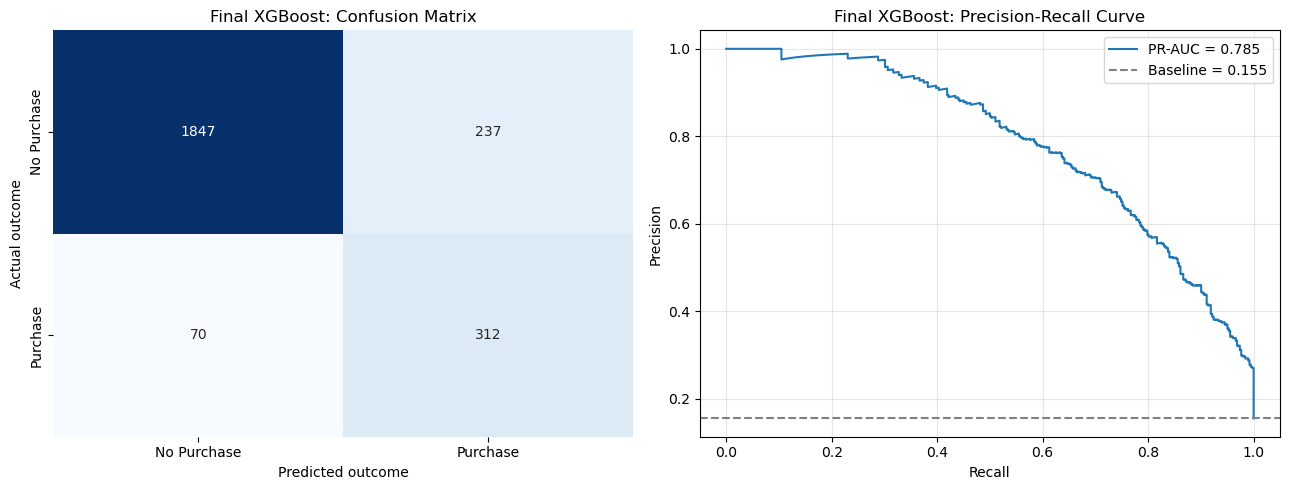

In [20]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    precision_recall_curve,
    average_precision_score
)

def evaluate_classifier(model, X, y, model_name="Model"):
    """Evaluate a binary classifier and plot its confusion matrix and PR curve."""

    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)[:, 1]

    metrics = {
        "Accuracy": accuracy_score(y, y_pred),
        "Precision": precision_score(y, y_pred, zero_division=0),
        "Recall": recall_score(y, y_pred, zero_division=0),
        "F1-score": f1_score(y, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y, y_proba)
    }

    display(
        pd.DataFrame([metrics], index=[model_name]).round(3)
    )

    cm = confusion_matrix(y, y_pred)

    curve_precision, curve_recall, _ = precision_recall_curve(
        y,
        y_proba
    )

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=["No Purchase", "Purchase"],
        yticklabels=["No Purchase", "Purchase"],
        ax=axes[0]
    )

    axes[0].set_title(f"{model_name}: Confusion Matrix")
    axes[0].set_xlabel("Predicted outcome")
    axes[0].set_ylabel("Actual outcome")

    axes[1].plot(
        curve_recall,
        curve_precision,
        label=f"PR-AUC = {metrics['PR-AUC']:.3f}"
    )

    axes[1].axhline(
        y=y.mean(),
        color="grey",
        linestyle="--",
        label=f"Baseline = {y.mean():.3f}"
    )

    axes[1].set_title(f"{model_name}: Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        "../reports/figures/final_model_evaluation.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return metrics


final_evaluation = evaluate_classifier(
    final_model,
    X_test_final,
    y_test,
    model_name="Final XGBoost"
)


#### Evaluation interpretation

The final model correctly identifies 312 of the 382 purchasing sessions and misses 70, resulting in a buyer recall of 81.7%. Of the 549 sessions predicted as purchasers, 312 actually purchased and 237 were false positives, producing a precision of 56.8%.

This trade-off reflects the model's recall-focused design: it captures most potential buyers but also includes a substantial number of non-buyers. It is therefore more appropriate for relatively low-cost targeting or remarketing than for expensive incentives.

The PR-AUC of 0.785 is substantially higher than the positive-class baseline of 0.155. This indicates that the model ranks purchasing sessions meaningfully better than random selection across different probability thresholds.

### 13.2 Feature Importance & Business Interpretation

Feature importance shows which variables contributed most strongly to the final XGBoost model's predictions. Higher importance means that a feature was used more frequently or more effectively when the model created its decision-tree splits.

Feature importance does not prove causation or show whether a feature increases or decreases purchase probability. It identifies the features that the model relied on most.

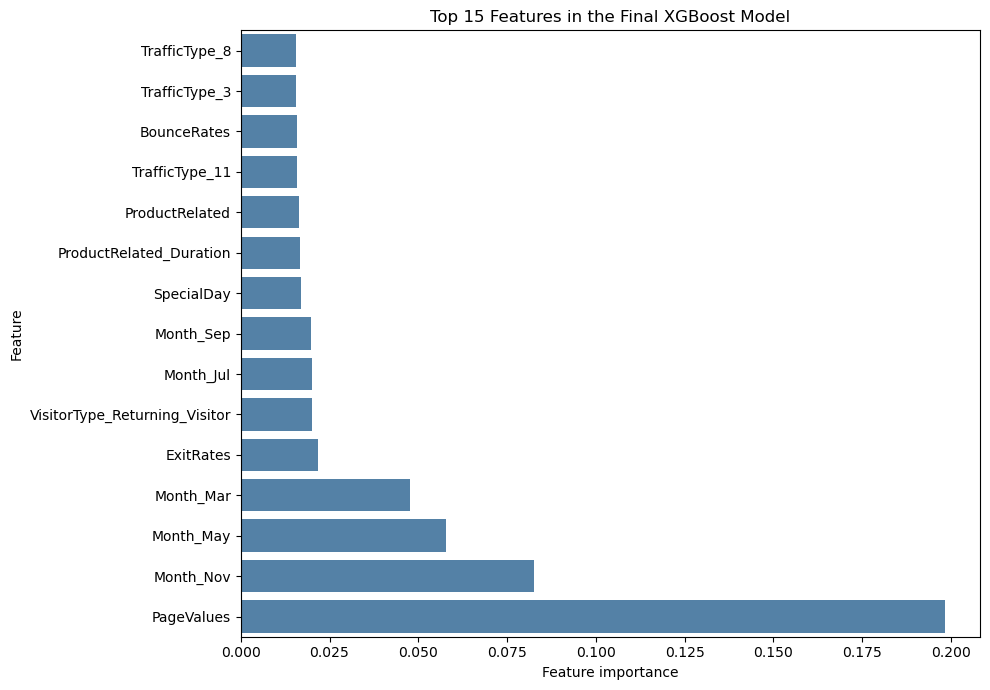

,Feature,Importance
0,PageValues,0.1983
1,Month_Nov,0.0826
2,Month_May,0.0579
3,Month_Mar,0.0477
4,ExitRates,0.0217
5,VisitorType_Returning_Visitor,0.0201
6,Month_Jul,0.0200
7,Month_Sep,0.0198
8,SpecialDay,0.0169
9,ProductRelated_Duration,0.0168


In [21]:
feature_importance_df = (
    pd.DataFrame({
        "Feature": X_train_final.columns,
        "Importance": final_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

top_features = (
    feature_importance_df
    .head(15)
    .sort_values("Importance", ascending=True)
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature",
    color="steelblue"
)

plt.title("Top 15 Features in the Final XGBoost Model")
plt.xlabel("Feature importance")
plt.ylabel("Feature")
plt.tight_layout()

plt.savefig(
    "../reports/figures/final_model_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

display(
    feature_importance_df
    .head(15)
    .reset_index(drop=True)
    .round(4)
)

#### Feature Importance Interpretation

- `PageValues` is the most influential feature by a substantial margin. This confirms that the model relies heavily on the estimated commercial value associated with pages visited during a session. Its dominance strengthens model performance but also makes the model dependent on the assumption that this metric is available at prediction time.

- Several month indicators, particularly November, May and March, are also important. This suggests that purchase behaviour varies across the year and that seasonal demand patterns contribute to prediction. Because one-hot encoding uses a reference month, these importance values should be interpreted relative to that omitted category.

- `ExitRates` and `BounceRates` show that session engagement and abandonment behaviour influence the model. `ProductRelated` and `ProductRelated_Duration` indicate that product-page exploration also contributes to purchase-intent prediction.

- `VisitorType_Returning_Visitor` suggests that visitor familiarity provides useful predictive information. Traffic-type features indicate differences in acquisition-source quality, although the numeric traffic codes would need to be mapped to their original channel definitions before translating them into specific marketing actions.

These importance scores show how strongly the model used each feature, but they do not show whether a feature increases or decreases purchase probability and do not prove causation.

### 13.3 PageValues Robustness Check

Because `PageValues` is the model's most influential feature and may not always be available during a live session, the final XGBoost configuration is also evaluated without this variable.

This is a fixed-configuration robustness comparison rather than a fully optimised no-`PageValues` model because the hyperparameters were originally selected using `PageValues`. The comparison therefore shows how dependent the current model is on this feature, not the best possible performance achievable without it.

In [22]:
# PageValues (Version without PageValues)
numerical_cols_no_pv = [col for col in numerical_cols if col != 'PageValues']

X_train_no_pv = pd.concat([X_train[numerical_cols_no_pv], X_train_cat_df], axis=1)
X_test_no_pv = pd.concat([X_test[numerical_cols_no_pv], X_test_cat_df], axis=1)

final_model_no_pv = XGBClassifier(
    n_estimators=400, learning_rate=0.02, subsample=0.8,
    colsample_bytree=0.7, reg_lambda=1, random_state=SEED,
    eval_metric='logloss', scale_pos_weight=scale_pos_weight
)
final_model_no_pv.fit(X_train_no_pv, y_train)

y_pred_no_pv = final_model_no_pv.predict(X_test_no_pv)
print(classification_report(y_test, y_pred_no_pv))


              precision    recall  f1-score   support

       False       0.93      0.70      0.80      2084
        True       0.30      0.71      0.42       382

    accuracy                           0.70      2466
   macro avg       0.62      0.70      0.61      2466
weighted avg       0.83      0.70      0.74      2466



#### Robustness Check Interpretation

- Removing `PageValues` reduces buyer precision from 56.8% to 30% and buyer recall from 81.7% to 71%. The buyer F1-score falls from 0.67 to 0.42, a relative decrease of approximately 37%.

- This confirms that the current model depends heavily on `PageValues`. Without it, the model still identifies many purchasing sessions but incorrectly classifies substantially more non-purchasing sessions as buyers.

- This result should be interpreted as a fixed-configuration robustness check. The no-`PageValues` model uses hyperparameters selected for the model containing `PageValues` and was not tuned separately. It therefore does not represent the best possible model without this feature.

## 14. Analysis & Results Summary

### Model Comparison

| Model | True Precision | True Recall | True F1-score |
|---|---|---|---|
| Dummy Classifier (baseline) | 0.00 | 0.00 | 0.00 |
| Random Forest (untuned) | 0.78 | 0.55 | 0.65 |
| XGBoost (untuned) | 0.73 | 0.59 | 0.65 |
| XGBoost (scale_pos_weight) | 0.59 | 0.71 | 0.65 |
| **XGBoost (tuned — final model)** | **0.57** | **0.82** | **0.67** |

The tuned XGBoost model achieved the highest F1-score for the minority class (`Revenue=True`), improving recall from 0.59 (untuned) to 0.82 while keeping F1 above all previous models. This means the final model correctly identifies **82% of actual purchasing sessions**, compared to only 59% before tuning — a substantial gain for a use case where missing a likely buyer is costly (e.g. retargeting campaigns).

The trade-off is a lower precision (0.57), meaning the model also flags more non-buyers as potential buyers. Given the business context (identifying sessions worth targeting for remarketing), prioritizing recall over precision is a reasonable choice.

### Tuning Process Impact

Three stages of hyperparameter tuning were applied, following the course methodology:

1. **Random Search** — CV F1-score: 0.6698
2. **Grid Search** (narrowed around Random Search results) — CV F1-score: 0.6756
3. **Manual Fine-Tuning** — CV F1-score: 0.6736 (did not surpass Grid Search)

The Grid Search configuration was retained as the final model because it achieved the strongest reported search score and used fewer trees than Manual Attempt 2. However, Grid Search and Manual Search used different cross-validation fold arrangements, so their scores are not strictly comparable. The differences were small and should be interpreted cautiously.

### PageValues — Leakage Risk Finding

A critical finding emerged when testing the final model with and without the `PageValues` feature:

| | With PageValues | Without PageValues |
|---|---|---|
| True F1-score | **0.67** | **0.42** |

Removing `PageValues` caused a ~37% drop in F1-score, revealing that a large share of the model's predictive power depends on this single feature. This is consistent with the EDA finding that `PageValues` is the strongest correlate of `Revenue`, and raises a legitimate concern about when this feature is actually available (it likely finalizes late in a session).

**Decision:** `PageValues` is retained in the official purchase-intent model under the explicit deployment assumption that this feature is available at scoring time without using the current session's final purchase outcome. The model is trained on historical purchasing and non-purchasing sessions. Potential applications include real-time targeting when the required inputs are available, remarketing prioritisation and website optimisation.

**Limitations:** 
- `PageValues` is retained under the assumption that it is available at scoring time without using the current session's final purchase outcome. If this assumption does not hold, the model would not be suitable for real-time deployment.
- The no-`PageValues` model is a fixed-configuration robustness check and was not tuned separately. Its F1-score of 0.42 should therefore not be interpreted as the best achievable performance without this feature.
- Duplicate rows were intentionally retained. Because the split was performed at row level, identical sessions may appear in both training and test sets, potentially producing optimistic performance estimates.
- The test set was used for several model comparisons and was therefore not fully untouched. Future work should use a separate validation set or nested cross-validation for stricter final evaluation.

### Key Takeaways
- Class imbalance made accuracy insufficient as the primary evaluation metric. The final model was therefore assessed using buyer-class precision, recall, F1-score, PR-AUC and a confusion matrix.
- The tuned XGBoost model achieved 81.7% buyer recall and an F1-score of 0.67. This higher recall came with lower precision of 56.8%, meaning that more actual buyers were identified but more non-buyers were also flagged.
- The PR-AUC of 0.785 is substantially above the positive-class baseline of 0.155, indicating useful separation between purchasing and non-purchasing sessions across different thresholds.
- `PageValues` is the dominant predictive feature and the model's main deployment dependency. Its availability at scoring time must be validated before real-time use.
- The model is most suitable for relatively low-cost targeting, remarketing prioritisation and website optimisation. Expensive incentives would require a higher-precision threshold and further business testing.

## Example: Scoring a Held-Out Session

This example treats one held-out session as a newly arriving session. The model returns the estimated probability that the session will end in a purchase.

In [23]:
# Example session scoring

demo_index = X_test_final.index[0]
demo_session = X_test_final.loc[[demo_index]]

purchase_probability = final_model.predict_proba(demo_session)[0, 1]
predicted_outcome = final_model.predict(demo_session)[0]

if hasattr(y_test, "loc"):
    actual_outcome = y_test.loc[demo_index]
else:
    actual_outcome = y_test[0]

print(f"Predicted purchase probability: {purchase_probability:.1%}")
print(
    f"Model prediction: "
    f"{'Purchase' if predicted_outcome else 'No purchase'}"
)
print(
    f"Actual outcome: "
    f"{'Purchase' if actual_outcome else 'No purchase'}"
)

Predicted purchase probability: 45.9%
Model prediction: No purchase
Actual outcome: No purchase
